### Soal 1 - Rute Antar Gedung

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

#Fungsi untuk menampilkan graf
def show_graph(G, pos=None, title='', labels=None):
    if labels is None:
        labels = {node: node for node in G.nodes()}
    if pos is None:
        pos = nx.spring_layout(G)
    nx.draw(
        G,
        pos,
        with_labels=True,
        labels=labels,
        node_color='red',
        node_size=2000,
        font_color="white",
        font_weight="bold",
        width=2
    )
    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels=edge_labels,
        font_color='blue',
        font_weight='bold',
        font_size=11
    )
    plt.margins(0.2)
    plt.title(title)
    plt.show()

#Membuat wadah graf
Graph = nx.Graph()
 
#Representasi Graf dalam dictionary adjacency list 
graph = {
    'A': [('B', 4), ('C', 2)], 
    'B': [('A', 4), ('D', 5)],        
    'C': [('A', 2), ('D', 4), ('E', 2), ('F', 1)],
    'D': [('B', 5), ('C', 4)], 
    'E': [('C', 2)], 
    'F': [('C', 1), ('A', 2)],
}

#Perulangan untuk memasukkan edge pada graf
for node, neighbors in graph.items():   #Perulangan-1 untuk mendapatkan isi key dan seluruh daftar isi tetangganya
    for neighbor, weight in neighbors:  #Perulangan-2 untuk mendapatkan isi tuple
        Graph.add_edge(node, neighbor, weight=weight) #Memasukkan weight pada graf

def heuristable(a,b):
    return 0

# Input Node Awal - Akhir oleh User
nodeStart = input('Masukkan node start [A-F] = ').upper()
nodeGoal = input('Masukkan node tujuan [A-F] = ').upper()

#Pengecekan apakah nodeStart dan nodeGoal ada pada graf
if nodeStart not in Graph or nodeGoal not in Graph:
    print(f"Node {nodeStart} atau node {nodeGoal} tidak ada dalam Graph")
    
else:
    #Pengecekan apakah terdapat jalur pada graf
    if nx.has_path(Graph, nodeStart, nodeGoal):
        path_node= nx.astar_path(Graph, nodeStart,nodeGoal, heuristic= heuristable, weight= 'weight')
        path_length= nx.astar_path_length(Graph, nodeStart,nodeGoal ,heuristic= heuristable, weight= 'weight')

        # Menampilkan graf
        show_graph(Graph, title=f"Rute Terpendek dari {nodeStart} ke {nodeGoal}")

        #Mencetak path dan cost
        print(f'\nNode dikunjungi dari {nodeStart} ke {nodeGoal}:', path_node)
        print(f"Total bobot (jarak) dari {nodeStart} ke {nodeGoal}:", path_length)
    else: 
        #Jika tidak memiliki jalur maka akan menampilkan pesan
        print(f"Jalur {nodeStart} - {nodeGoal} Tidak ditemukan")




Node A atau node G tidak ada dalam Graph


### Soal 2 - Logistik

Daftar Kota: Jakarta, Bandung, Cirebon, Tasikmalaya, Semarang, Yogya

HASIL PENCARIAN RUTE TERBAIK (A* as UCS):
1. Jalur Terbaik         : Jakarta -> Bandung -> Tasikmalaya -> Yogya
2. Total Biaya (Waktu)   : 11 Jam
3. Urutan Ekspansi Node  : Jakarta -> Bandung -> Cirebon -> Tasikmalaya -> Semarang -> Yogya
4. Node yang dikunjungi  : ['Jakarta', 'Bandung', 'Cirebon', 'Tasikmalaya', 'Semarang', 'Yogya']


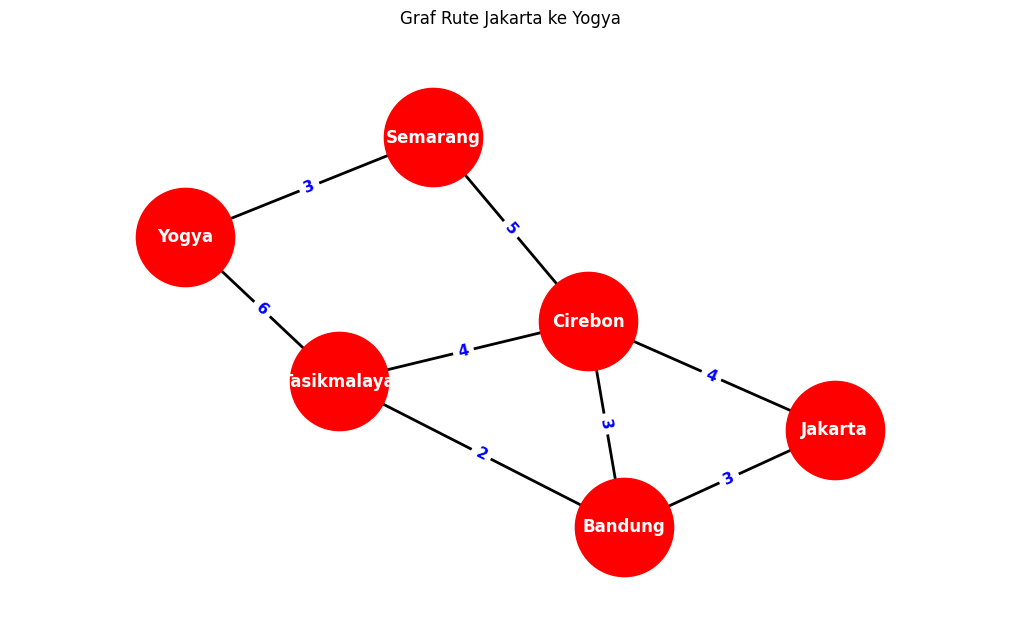

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Fungsi untuk menampilkan graf
def show_graph(G, pos=None, title='', labels=None):
    if labels is None:
        labels = {node: node for node in G.nodes()}
    if pos is None:
        pos = nx.spring_layout(G, seed=42)
    
    plt.figure(figsize=(10, 6))
    nx.draw(
        G, pos, with_labels=True, labels=labels,
        node_color='red', node_size=5000,
        font_color="white", font_weight="bold", width=2
    )
    
    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(
        G, pos, edge_labels=edge_labels,
        font_color='blue', font_weight='bold', font_size=11
    )
    plt.margins(0.2)
    plt.title(title)
    plt.show()

# Membuat wadah graf
Graph = nx.Graph()

# Representasi Graf dalam dictionary adjacency list 
graph = {
    'Jakarta': [('Bandung', 3), ('Cirebon', 4)],
    'Bandung': [('Jakarta', 3), ('Tasikmalaya', 2), ('Cirebon', 3)],
    'Cirebon': [('Jakarta', 4), ('Bandung', 3), ('Semarang', 5), ('Tasikmalaya', 4)],
    'Tasikmalaya': [('Bandung', 2), ('Cirebon', 4), ('Yogya', 6)],
    'Semarang': [('Cirebon', 5), ('Yogya', 3)],
    'Yogya': [('Tasikmalaya', 6), ('Semarang', 3)]
}

# Perulangan untuk memasukkan edge pada graf
for kota, tetangga in graph.items():
    for tujuan, biaya in tetangga:
        Graph.add_edge(kota, tujuan, weight=biaya)


def heuristable(a, b):
    return 0

# Input Node Awal - Akhir oleh User
print("Daftar Kota: Jakarta, Bandung, Cirebon, Tasikmalaya, Semarang, Yogya")
nodeStart = input('Masukkan kota awal start = ').title()
nodeGoal = input('Masukkan kota tujuan = ').title()

# Pengecekan apakah nodeStart dan nodeGoal ada pada graf
if nodeStart in Graph and nodeGoal in Graph:
    # 1. Mencari Jalur Terbaik dengan nx.astar_path
    jalur = nx.astar_path(Graph, nodeStart, nodeGoal, heuristic=heuristable, weight='weight')
    
    # 2. Mencari Total Biaya dengan nx.astar_path_length
    total_biaya = nx.astar_path_length(Graph, nodeStart, nodeGoal, heuristic=heuristable, weight='weight')
    
    # 3. Mendapatkan data ekspansi (Node yang dijangkau dan urutannya)
    # single_source_dijkstra memberikan jarak kumulatif yang digunakan UCS untuk ekspansi
    distances, paths = nx.single_source_dijkstra(Graph, nodeStart)
    
    # Urutan Ekspansi: Node yang diproses berdasarkan biaya terkecil dari start
    ekspansi = sorted(distances, key=distances.get)
    
    # Output Hasil
    print("\n" + "-"*45)
    print(f"HASIL PENCARIAN RUTE TERBAIK:")
    print(f"1. Jalur Terbaik         : {' -> '.join(jalur)}")
    print(f"2. Total Biaya (Waktu)   : {total_biaya} Jam")
    print(f"3. Urutan Ekspansi Node  : {' -> '.join(ekspansi)}")
    print(f"4. Node yang dikunjungi  : {list(distances.keys())}")
    print("-"*45)
    
    # Menampilkan Visualisasi
    show_graph(Graph, title=f"Graf Rute {nodeStart} ke {nodeGoal}")
else:
    print(f"\nKesalahan: Kota {nodeStart} atau {nodeGoal} tidak ditemukan dalam daftar.")